# Applied Machine Learning Lab
NumPy Foundations with ECG Signal Processing

Course: Applied Machine Learning
Primary Library: NumPy
Dataset: mitbih_train.csv

## 1. Introduction

Electrocardiography (ECG) records the electrical activity of the heart over time.
Each heartbeat produces a waveform consisting of P wave, QRS complex, and T wave.

The QRS complex contains the largest spike, called the R-peak, which corresponds to ventricular depolarization.

Detecting these peaks is useful for:

Heartbeat detection

Arrhythmia analysis

Heart rate estimation

In this lab, we use NumPy-based numerical operations to process ECG signals.
The goal is to explore:

Array manipulation

Broadcasting-based standardization

Convolution for smoothing

Threshold-based peak detection

## 2. Dataset Description

The dataset mitbih_train.csv originates from the MIT-BIH Arrhythmia Database, which is widely used in biomedical signal processing research.

Dataset Structure
Property	Value
Total samples	87,554
Signal length	187
Target column	1
Total columns	188
Interpretation

Each row represents one ECG recording.

The first 187 columns represent ECG amplitude values over time.

The last column represents the heartbeat class label.

Thus, every row is essentially a time-series signal describing a heartbeat.

## 3. Import Required Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

NumPy → numerical operations and arrays

Pandas → reading the dataset

Matplotlib → visualizing ECG signals

## 4. Load the Dataset

In [5]:
ecg = pd.read_csv("mitbih_train.csv")

read_csv() loads the dataset.

shape shows number of rows and columns.

Expected shape:

(87554, 188)

Meaning:

87554 ECG signals

187 signal values

1 class label

## 5. Separate Signal Data and Labels

In [7]:
X = ecg.iloc[:, :-1].values
y = ecg.iloc[:, -1].values

print("Signal shape:", X.shape)
print("Target shape:", y.shape)

Signal shape: (87553, 187)
Target shape: (87553,)


X contains ECG signal values.

y contains the target class.

:-1 selects all columns except the last.

## 6. Standardization Using NumPy Broadcasting

ECG signals may have different amplitude ranges.
To normalize them we use standardization.

Formula:
        𝑧=𝑥−𝜇/𝜎
Where:
μ = mean
σ = standard deviation

In [11]:
mean = np.mean(X, axis=1, keepdims=True)
std = np.std(X, axis=1, keepdims=True)

X_standardized = (X - mean) / std

axis=1 → compute mean per signal.

keepdims=True → keeps dimensions for broadcasting.

Division by std scales the data.

## Deliverable 1: Verify Standardization

In [12]:
print("Mean :", np.mean(X_standardized[0]))
print("Std :", np.std(X_standardized[0]))

Mean : -1.8998468870590913e-17
Std : 1.000000000000001


## 7. Select a Sample ECG Signal

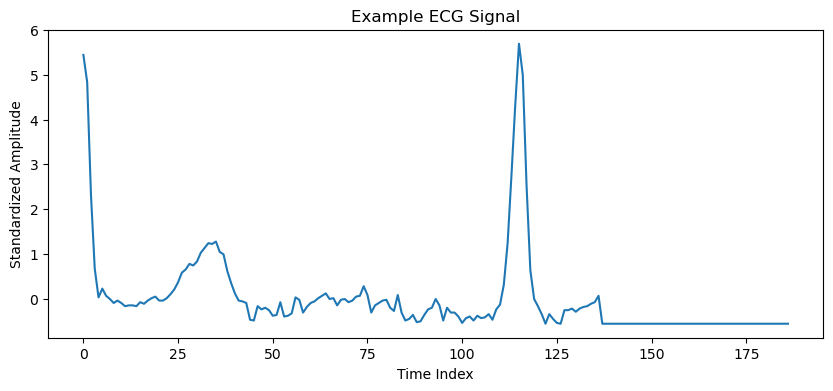

In [13]:
sample_signal = X_standardized[0]

plt.figure(figsize=(10,4))
plt.plot(sample_signal)
plt.title("Example ECG Signal")
plt.xlabel("Time Index")
plt.ylabel("Standardized Amplitude")
plt.show()

sample_signal selects one ECG signal.

plot() visualizes the waveform.

## 8. Convolution for Signal Smoothing

Convolution is used to reduce noise in signals.

A kernel (filter) slides across the signal and computes a local average.

Example kernel:

In [14]:

kernel = np.ones(5) / 5



This means each point becomes the average of 5 neighboring values

## Deliverable 2: Apply Convolution (Kernel = 5)

In [16]:
kernel5 = np.ones(5) / 5

smoothed_signal = np.convolve(sample_signal, kernel5, mode='same')

np.ones(5) creates a kernel of size 5.

Division by 5 creates an averaging filter.

mode='same' keeps output size equal to input.

## 9. Plot Original vs Smoothed Signal

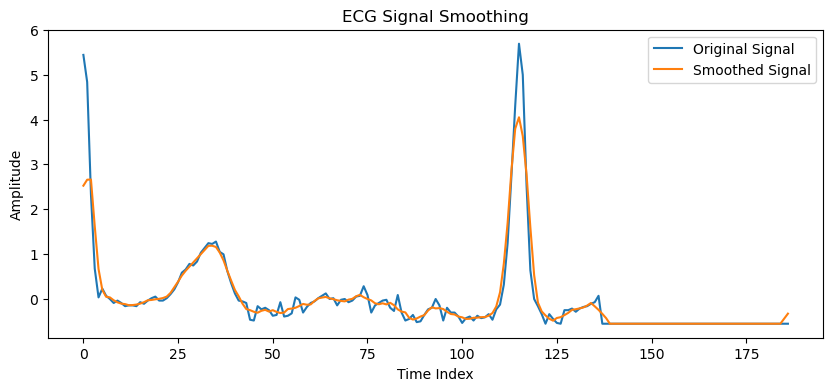

In [17]:
plt.figure(figsize=(10,4))

plt.plot(sample_signal, label="Original Signal")
plt.plot(smoothed_signal, label="Smoothed Signal")

plt.legend()
plt.title("ECG Signal Smoothing")
plt.xlabel("Time Index")
plt.ylabel("Amplitude")

plt.show()

Observation

After smoothing:

Noise spikes decrease

Main peaks remain visible

## 10. Threshold-Based Peak Detection

A threshold determines which values are considered peaks.

Since signals were standardized:

Threshold = 2 → strong peaks

Threshold = 3 → very strong peaks

Peak counting is done using:

In [22]:
sample_signal = X_standardized[0]

threshold = 2

peaks = np.sum(sample_signal > threshold)

print("Detected Peaks:", peaks)

Detected Peaks: 8


threshold = 2 → sets the value used to detect peaks.

sample_signal > threshold → checks which signal values are above the threshold.

np.sum() → counts how many values satisfy the condition.

## Deliverable 3: Compare Threshold 2 and 3

In [23]:
threshold2_before = np.sum(sample_signal > 2)
threshold2_after = np.sum(smoothed_signal > 2)

threshold3_before = np.sum(sample_signal > 3)
threshold3_after = np.sum(smoothed_signal > 3)

print("Threshold 2")
print("Before smoothing:", threshold2_before)
print("After smoothing:", threshold2_after)

print("\nThreshold 3")
print("Before smoothing:", threshold3_before)
print("After smoothing:", threshold3_after)

Threshold 2
Before smoothing: 8
After smoothing: 8

Threshold 3
Before smoothing: 5
After smoothing: 3


If peaks decrease → noise removed.

If peaks drop too much → kernel too large

## Exercise 1: Test Different Thresholds

In [24]:
thresholds = [1.5, 2, 2.5, 3]

for t in thresholds:
    peaks = np.sum(sample_signal > t)
    print(f"Threshold {t} → {peaks} peaks")

Threshold 1.5 → 8 peaks
Threshold 2 → 8 peaks
Threshold 2.5 → 7 peaks
Threshold 3 → 5 peaks


Observation:

Higher thresholds produce fewer peaks.

## Exercise 2: Test Different Kernel Sizes

In [25]:
for k in [3,5,9]:

    kernel = np.ones(k)/k
    smooth = np.convolve(sample_signal, kernel, mode='same')

    peaks = np.sum(smooth > 2)

    print(f"Kernel {k} → {peaks} peaks")

Kernel 3 → 8 peaks
Kernel 5 → 8 peaks
Kernel 9 → 6 peaks


Kernel 3 → light smoothing

Kernel 5 → balanced smoothing

Kernel 9 → strong smoothing

## Exercise 3: Visual Comparison

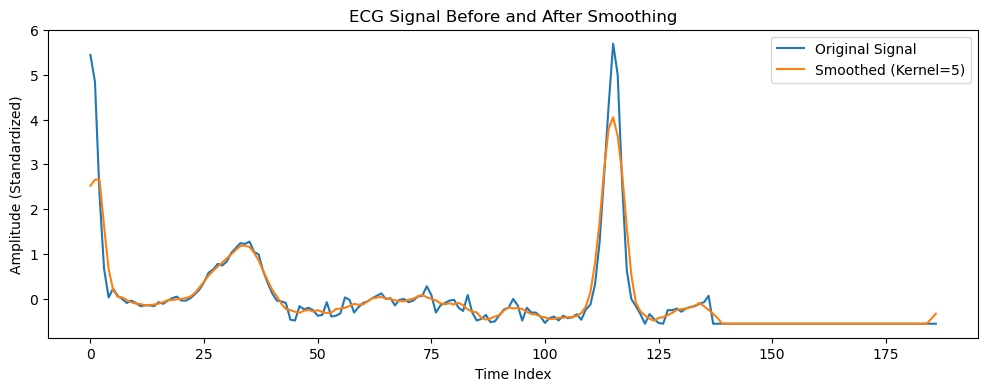

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.plot(sample_signal, label="Original Signal")
plt.plot(smoothed_signal, label="Smoothed (Kernel=5)")

plt.legend()
plt.title("ECG Signal Before and After Smoothing")
plt.xlabel("Time Index")
plt.ylabel("Amplitude (Standardized)")

plt.show()

### Visualizing ECG Signal Before and After Smoothing

To observe the effect of convolution smoothing, the original ECG signal is plotted
together with the smoothed signal obtained using a kernel size of 5. The comparison
helps visualize how noise spikes are reduced while the main QRS peaks remain visible.`

## Exercise 4: Global Maximum Peak
np.max() finds the highest value per ECG signal

In [29]:
global_peaks = np.max(X_standardized, axis=1)

print(global_peaks[:10])

[5.69733039 6.75867489 5.69526006 4.74577471 2.97782382 2.10174658
 4.86729809 3.14852236 5.26148626 5.3613093 ]


## Exercise 5: Location of Highest Peak

In [30]:
peak_locations = np.argmax(X_standardized, axis=1)

print(peak_locations[:10])

[115   0  80   1   1   2  77 104   0  79]


argmax() returns the index where the peak occurs.

## Exercise 6: Loop vs Vectorized Peak Counting

In [31]:
threshold = 2
count_loop = 0

for value in sample_signal:
    if value > threshold:
        count_loop += 1

print("Loop count:", count_loop)

Loop count: 8


Vectorized Method:
Vectorized operations are faster and more efficient.

In [32]:
count_vectorized = np.sum(sample_signal > threshold)

print("Vectorized count:", count_vectorized)

Vectorized count: 8


## Exercise 7: Kernel and Threshold Interaction

In [33]:
for k in [3,5,9]:

    kernel = np.ones(k)/k
    smooth = np.convolve(sample_signal, kernel, mode='same')

    print(f"\nKernel {k}")

    for t in [1.5,2,2.5,3]:
        peaks = np.sum(smooth > t)
        print(f"Threshold {t} → {peaks} peaks")


Kernel 3
Threshold 1.5 → 8 peaks
Threshold 2 → 8 peaks
Threshold 2.5 → 8 peaks
Threshold 3 → 5 peaks

Kernel 5
Threshold 1.5 → 11 peaks
Threshold 2 → 8 peaks
Threshold 2.5 → 8 peaks
Threshold 3 → 3 peaks

Kernel 9
Threshold 1.5 → 10 peaks
Threshold 2 → 6 peaks
Threshold 2.5 → 0 peaks
Threshold 3 → 0 peaks


Observation:

Larger kernels reduce noise.

Higher thresholds reduce detected peaks

## Conclusion

In this experiment, NumPy was used to perform fundamental ECG signal processing tasks.
Standardization ensured that signals had comparable amplitude ranges, enabling consistent peak detection. Convolution smoothing reduced random noise while preserving the main structure of the ECG waveform. Threshold-based peak detection was then applied to identify significant signal spikes corresponding to potential R-peaks in the QRS complex.

The results showed that kernel size and threshold selection strongly influence peak detection. Smaller kernels preserve sharp peaks but remove less noise, while larger kernels provide stronger smoothing but may flatten important peaks. Similarly, lower thresholds detect more peaks but may include noise, whereas higher thresholds detect only the most significant spikes.

Overall, this lab demonstrates how simple NumPy operations can be used for practical biomedical signal processing tasks.